# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [51]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [52]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [53]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [54]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [55]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [56]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [57]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [58]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [59]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [60]:

# cantidad de nulos para users
users.isna().sum
#La columna city cuenta con 11.8% recomiendo investigar e imputar para dejar como nulo.
#la columna churn_date cuenta con 89.% se recomienda ignorar para inputación (o eliminar sino se utilizará)





<bound method NDFrame._add_numeric_operations.<locals>.sum of       user_id  first_name  last_name    age   city  reg_date   plan  \
0       False       False      False  False  False     False  False   
1       False       False      False  False  False     False  False   
2       False       False      False  False  False     False  False   
3       False       False      False  False  False     False  False   
4       False       False      False  False  False     False  False   
...       ...         ...        ...    ...    ...       ...    ...   
3995    False       False      False  False  False     False  False   
3996    False       False      False  False  False     False  False   
3997    False       False      False  False  False     False  False   
3998    False       False      False  False  False     False  False   
3999    False       False      False  False  False     False  False   

      churn_date  
0           True  
1           True  
2           True  
3        

In [61]:

# cantidad de nulos para usage
usage.isna().sum()
# la columna date tiene .02% de nulo se recomienda imputar o eliminar registros. Siendo un porcentaje bajo se puede corregir sin afectar el analisis.
# la columna duration tiene 9.63% se recomienda investigar y mantener como nulos. 
# la columna length tiene 7.81% se recomienda investigar y mantener como nulos.

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  data set de usuarios
  city: 469 valores nulos (11.8% del total).
  churn_date: 3534 valores nulos (89.0% del total).

  data set de usage, 
  date: 50 valores nulos (0.02%).
  duration: 22,076 valores nulos (9.63%).
  length: 17,896 valores nulos (7.81%)
  
- Indica qué harías: ¿imputar, eliminar, ignorar?

- data set de usuarios
- city: Investigar la causa de los nulos y, dependiendo del análisis, imputar el valor (por ejemplo, con la ciudad más frecuente) o mantener los nulos si no afectan el análisis.
- churn_date: No imputaría los valores, ya que los nulos indican que el cliente continúa activo. Solo eliminaría la columna si no fuera necesaria para el análisis o el modelo.

- data set de usage
date: Imputaría o eliminaría esos pocos registros, ya que representan una proporción mínima del conjunto de datos.
duration: No imputaría los nulos; investigaría su origen porque corresponden a registros donde la duración no aplica (mensajes).
length: No imputaría los nulos; los mantendría porque representan registros donde la longitud del mensaje no aplica (llamadas).



### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [62]:


# explorar columnas numéricas de users
users.describe()



,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` contiene identificadores únicos que van del 10000 al 13999, por lo que no presenta anomalías aparentes
- La columna `age` se observa un valor mínimo de -999, el cual es imposible para una edad y corresponde a un valor sentinel. Este valor afecta la media (33.74) y la desviación estándar (123.23), haciéndolas poco representativas. La mediana (47 años) y el rango restante de edades (hasta 79 años) son consistentes con valores esperados para los usuarios.

In [63]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas de users
  `id` Los identificadores van de 10000 a 13999, sin valores faltantes ni anomalías aparentes. Al ser un identificador, no requiere análisis estadístico adicional.
  `user_id` Se observa un valor mínimo de -999, lo cual es imposible para una edad y sugiere la presencia de un valor sentinel utilizado para representar datos faltantes o inválidos. Además, este valor hace que la media (33.74) y la desviación estándar (123.23) no sean representativas. El resto de las edades (hasta 79 años) parecen razonables..
- Las columnas de usage
  `id`Los identificadores van de 1 a 40000, sin valores fuera del rango esperado. Al ser una llave única, no requiere tratamiento.
  `user_id`Los identificadores de usuario se encuentran entre 10000 y 13999, lo que coincide con el dataset users y no presenta valores inválidos.
  `duration` La duración de las llamadas varía entre 0 y 120 minutos. No se observan valores negativos ni sentinels como -999. El valor 0 podría corresponder a llamadas no completadas o de duración nula, por lo que conviene investigarlo antes de decidir si debe conservarse o eliminarse.
  `length`La longitud de los mensajes va de 0 a 1490 caracteres. No hay valores negativos ni sentinels. Los valores 0 pueden representar mensajes vacíos o registros especiales, por lo que también es recomendable revisar su significado.

In [64]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\n--- {col} ---")
    print("Valores únicos:")
    print(users[col].unique())

    print("\nFrecuencia de cada valor:")
    print(users[col].value_counts(dropna=False))



--- city ---
Valores únicos:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Frecuencia de cada valor:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

--- plan ---
Valores únicos:
['Basico' 'Premium']

Frecuencia de cada valor:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city`
contiene las ciudades esperadas (Bogotá, CDMX, Medellín, GDL, Cali y MTY), pero también presenta 469 valores nulos y 96 registros con el valor ?, el cual representa un valor sentinel o dato inválido. Se recomienda reemplazar ? por NaN para tratar ambos casos de forma consistente durante la limpieza de datos.
- La columna `plan`
  La columna plan únicamente contiene las categorías Basico y Premium, que son valores válidos. No se detectan categorías inesperadas ni sentinels.

In [65]:

# explorar columna categórica de usage
#usage['type'] # completa el código
print("Valores únicos:")
print(usage['type'].unique())

print("\nFrecuencia de cada valor:")
print(usage['type'].value_counts(dropna=False))


Valores únicos:
['call' 'text']

Frecuencia de cada valor:
text    22092
call    17908
Name: type, dtype: int64


- La columna `type` contiene únicamente las categorías call y text, que corresponden a los dos tipos de uso esperados del servicio. No se observan valores nulos, categorías inesperadas ni valores sentinel, por lo que la columna no requiere limpieza adicional.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
   age, city
- ¿Qué acción tomarías?
- age: Reemplazar el valor -999 por NaN para tratarlo posteriormente mediante imputación o eliminación, según el análisis.
city: Reemplazar el valor ? por NaN, ya que representa un dato faltante, y después decidir una estrategia de imputación o mantener los valores nulos.

 y solo en caso particular para usage: No realizar cambios, ya que no se encontraron valores sentinel. Solo analizar los registros con valor 0 para confirmar que correspondan a datos válidos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [66]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [67]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')


In [68]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, La mayoría de los registros pertenecen a los años 2022, 2023 y 2024, que están dentro del rango esperado. Sin embargo, se identificaron 40 registros con fecha de 2026, un año posterior al límite establecido (2024), por lo que se consideran fechas inválidas o posibles errores de captura.Se recomienda revisar los 40 registros con fecha de 2026 para confirmar si se trata de un error de captura. En caso de no poder corregir la fecha con información confiable, deberían reemplazarse por NaT o excluirse del análisis para evitar sesgos en los resultados.

In [69]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, Todos los registros con fecha válida pertenecen al año 2024, que se encuentra dentro del rango esperado. No se identifican años futuros ni fechas imposibles. 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- Sí. En el dataset users, la columna reg_date contiene 40 registros del año 2026, el cual está fuera del rango esperado, ya que se indicó que los datos solo están registrados hasta el año 2024. Estas fechas se consideran inválidas o posibles errores de captura.

En el dataset usage, no se encontraron años imposibles. Todos los registros con fecha válida corresponden al año 2024, que está dentro del rango esperado.

- ¿Qué harías con ellas?
- users['reg_date']: Revisaría los 40 registros con fechas del año 2026 para verificar si se trata de un error de captura. Si no es posible corregirlos con información confiable, reemplazaría esas fechas por NaT o eliminaría esos registros, dependiendo del objetivo del análisis.
usage['date']: No realizaría ninguna corrección, ya que no se detectaron años fuera del rango esperado.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [70]:

# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [71]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

#users['city'].unique()


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [72]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()





2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [73]:
# Verificación MAR en usage (Missing At Random) para duration
# Crear indicador de valores nulos en duration
usage['duration_is_null'] = usage['duration'].isna()

# Relación entre tipo de evento y nulos en duration
usage.groupby('type')['duration_is_null'].mean()

type
call    0.000000
text    0.999276
Name: duration_is_null, dtype: float64

In [74]:
# Verificación MAR en usage (Missing At Random) para length
# Crear indicador de valores nulos en length
usage['length_is_null'] = usage['length'].isna()

# Relación entre tipo de evento y nulos en length
usage.groupby('type')['length_is_null'].mean()

type
call    0.99933
text    0.00000
Name: length_is_null, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en 
`duration`
Los valores nulos en duration están prácticamente concentrados en el tipo text (≈ 99.93%), mientras que en call no hay nulos.
Esto indica que la duración no aplica para los mensajes de texto.Los nulos en duration son MAR (Missing At Random) porque dependen directamente del tipo de evento (type).
`length`
Los valores nulos en length están casi completamente en el tipo call (≈ 99.93%), mientras que en text no hay nulos.
Esto indica que la longitud del mensaje no aplica para las llamadas.Los nulos en length también son MAR (Missing At Random), ya que dependen del tipo de interacción.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [75]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()



# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [76]:
# Renombrar columnas
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})


# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [77]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")

# Ver resultado
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [78]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

user_profile[columnas_numericas].describe()
# Mediana de las variables numéricas
user_profile[columnas_numericas].median()


age                     48.00
cant_mensajes            5.00
cant_llamadas            4.00
cant_minutos_llamada    19.78
dtype: float64

In [79]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True).mul(100).round(2)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

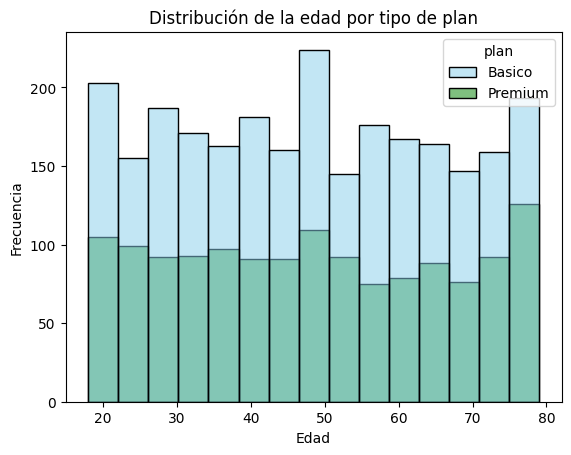

In [80]:

# Histograma para visualizar la edad (age)

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=15
)

plt.title('Distribución de la edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- La distribución de la edad es relativamente uniforme entre los 18 y 79 años para ambos planes. No se observa un patrón claro que indique que un grupo de edad prefiera el plan Básico o Premium. La distribución puede considerarse aproximadamente simétrica, sin concentraciones marcadas en un rango específico.

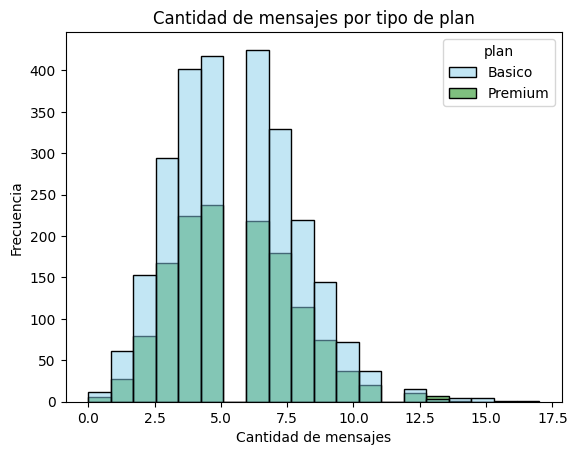

In [81]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Cantidad de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La mayoría de los usuarios envía entre 3 y 7 mensajes. La distribución presenta un sesgo a la derecha, ya que pocos usuarios envían una cantidad elevada de mensajes. No se observan diferencias importantes entre los planes Básico y Premium, por lo que no parece existir un patrón de uso asociado al tipo de plan.

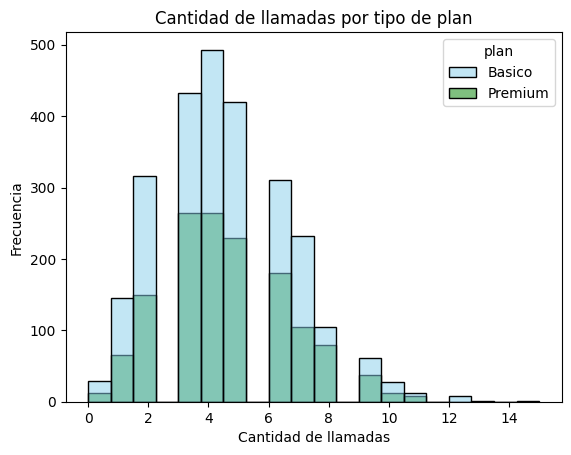

In [82]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Cantidad de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La mayor parte de los usuarios realiza entre 2 y 6 llamadas. La distribución está sesgada a la derecha, debido a que un pequeño número de usuarios realiza muchas llamadas. Ambos planes muestran un comportamiento muy similar, por lo que no se aprecia un patrón claro que diferencie el número de llamadas entre los usuarios de Básico y Premium.

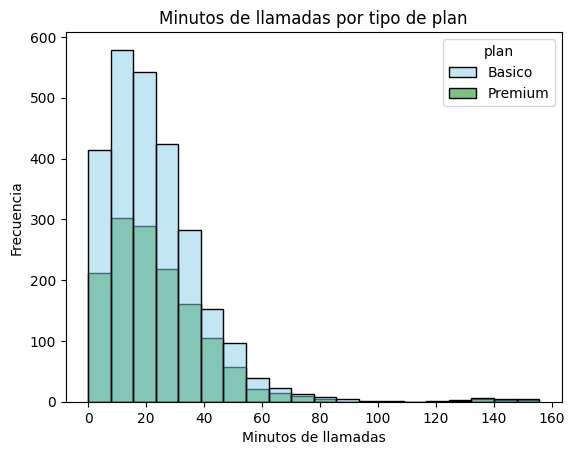

In [83]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20
)

plt.title('Minutos de llamadas por tipo de plan')
plt.xlabel('Minutos de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La mayoría de los usuarios acumula pocos minutos de llamadas, mientras que solo unos cuantos presentan un consumo muy alto. La distribución está fuertemente sesgada a la derecha, lo que indica la presencia de usuarios con un uso intensivo del servicio. No se observan diferencias relevantes entre los planes Básico y Premium, ya que ambos presentan una distribución muy parecida.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

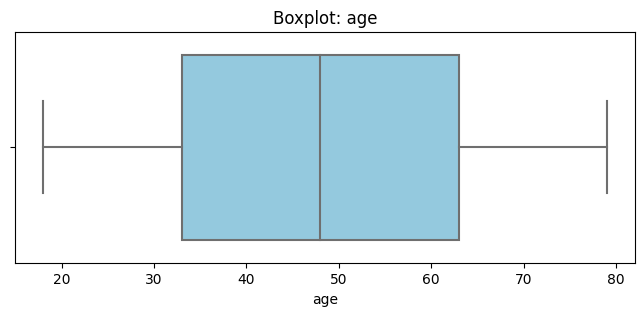

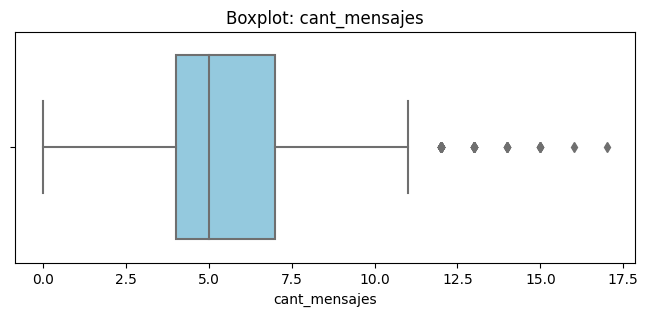

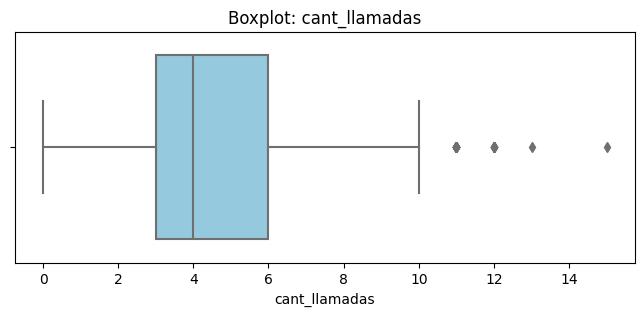

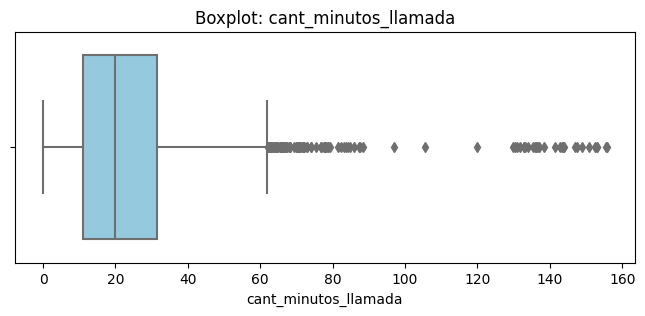

In [84]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 3))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()


💡Insights: 
- Age: La variable age no presenta valores atípicos una vez corregido el valor sentinel (-999). La mediana se encuentra alrededor de los 47 años y el rango intercuartílico concentra usuarios entre aproximadamente 35 y 64 años. La ausencia de outliers indica una población bien distribuida y sin edades extremas que puedan sesgar el análisis estadístico. Esto sugiere que la base de clientes es demográficamente estable y que la edad, por sí sola, no representa un factor de riesgo para los análisis posteriores.
- cant_mensajes: La mayoría de los usuarios envía entre 4 y 7 mensajes, mientras que existe un grupo reducido que supera los 11 mensajes, identificado como outlier. Estos casos representan clientes con un uso significativamente superior al comportamiento típico. Dado que los valores extremos aparecen únicamente en la cola superior y no existen anomalías inferiores, es probable que correspondan a usuarios con mayor actividad y no a errores de captura.
- cant_llamadas: La distribución de llamadas es relativamente compacta, concentrándose entre 3 y 6 llamadas por usuario. Sin embargo, se observa un pequeño grupo de usuarios que realiza entre 11 y 15 llamadas, claramente separado del resto de la población. Estos valores extremos son pocos y no afectan la tendencia general del conjunto de datos.
- cant_minutos_llamada: Esta es la variable con la mayor cantidad de valores atípicos. La mayoría de los usuarios consume menos de 35 minutos, mientras que existe una larga cola de usuarios con consumos superiores a 60 minutos, llegando incluso a más de 150 minutos. La elevada concentración de outliers únicamente en el extremo superior indica una distribución altamente asimétrica.

In [85]:



# Calcular límites con el método IQR
for col in columnas_numericas:

    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = user_profile[
        (user_profile[col] < limite_inferior) |
        (user_profile[col] > limite_superior)
    ]

    print(f'\n{col}')
    print(f'Q1: {Q1:.2f}')
    print(f'Q3: {Q3:.2f}')
    print(f'IQR: {IQR:.2f}')
    print(f'Límite inferior: {limite_inferior:.2f}')
    print(f'Límite superior: {limite_superior:.2f}')
    print(f'Cantidad de outliers: {len(outliers)}')







age
Q1: 33.00
Q3: 63.00
IQR: 30.00
Límite inferior: -12.00
Límite superior: 108.00
Cantidad de outliers: 0

cant_mensajes
Q1: 4.00
Q3: 7.00
IQR: 3.00
Límite inferior: -0.50
Límite superior: 11.50
Cantidad de outliers: 46

cant_llamadas
Q1: 3.00
Q3: 6.00
IQR: 3.00
Límite inferior: -1.50
Límite superior: 10.50
Cantidad de outliers: 30

cant_minutos_llamada
Q1: 11.12
Q3: 31.41
IQR: 20.30
Límite inferior: -19.32
Límite superior: 61.86
Cantidad de outliers: 109


In [86]:
# Variables que presentan outliers
columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()



,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Mantener los outliers. La variable presenta un comportamiento relativamente estable, con una mediana de 5 mensajes y un rango intercuartílico entre 4 y 7 mensajes, lo que indica que el 50% de los usuarios tiene un nivel de uso muy similar. Aunque existen usuarios que alcanzan hasta 17 mensajes, estos valores representan aproximadamente 2.4 veces el tercer cuartil, una diferencia que sigue siendo razonable dentro del contexto operativo del servicio. No existen evidencias de errores de captura ni valores imposibles.
- cant_llamadas: Mantener los outliers.El comportamiento de las llamadas es bastante homogéneo: el 50% de los usuarios realiza entre 3 y 6 llamadas, con una mediana de 4 llamadas. Los usuarios con hasta 15 llamadas aparecen como valores atípicos bajo el criterio del IQR; sin embargo, el máximo observado no es excesivamente distante respecto al comportamiento general y resulta consistente con clientes que utilizan con mayor frecuencia el servicio de voz.
- cant_minutos_llamada: Mantener los outliers.Esta variable presenta la mayor dispersión del conjunto de datos (desviación estándar de 18.17 minutos) y una marcada asimetría positiva. Mientras que el 75% de los usuarios consume hasta 31.42 minutos, el máximo alcanza 155.69 minutos, evidenciando un pequeño grupo de usuarios con un patrón de consumo significativamente superior al promedio. En servicios de telecomunicaciones este comportamiento es esperado, ya que normalmente una minoría de clientes concentra una proporción importante del consumo total.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [87]:
# Crear columna grupo_uso
# Condiciones
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

# Valores a asignar
categorias = ['Bajo uso', 'Uso medio']

# Crear columna grupo_uso
user_profile['grupo_uso'] = np.select(
    condiciones,
    categorias,
    default='Alto uso'
)

# Verificar resultado
user_profile[['user_id', 'cant_llamadas', 'cant_mensajes', 'grupo_uso']].head()

,user_id,cant_llamadas,cant_mensajes,grupo_uso
0,10000,3.0,7.0,Uso medio
1,10001,10.0,5.0,Alto uso
2,10002,2.0,5.0,Uso medio
3,10003,3.0,11.0,Alto uso
4,10004,3.0,4.0,Bajo uso


In [88]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [89]:
# Crear columna grupo_edad
# Condiciones para la edad
condiciones = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]

# Categorías
categorias = ['Joven', 'Adulto']

# Crear la columna grupo_edad
user_profile['grupo_edad'] = np.select(
    condiciones,
    categorias,
    default='Adulto Mayor'
)

# Verificar resultados
user_profile[['user_id', 'age', 'grupo_edad']].head()

,user_id,age,grupo_edad
0,10000,38.0,Adulto
1,10001,53.0,Adulto
2,10002,57.0,Adulto
3,10003,69.0,Adulto Mayor
4,10004,63.0,Adulto Mayor


In [90]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

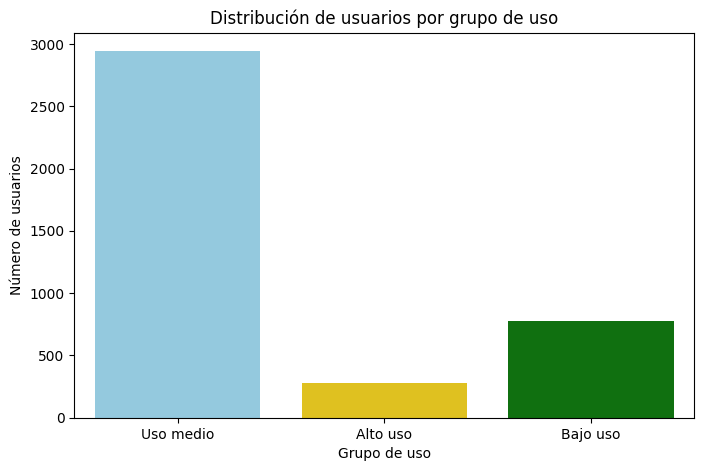

In [91]:

# Visualización de los segmentos por uso
plt.figure(figsize=(8,5))

sns.countplot(
    data=user_profile,
    x='grupo_uso',
    palette=['skyblue', 'gold', 'green']
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Número de usuarios')

plt.show()


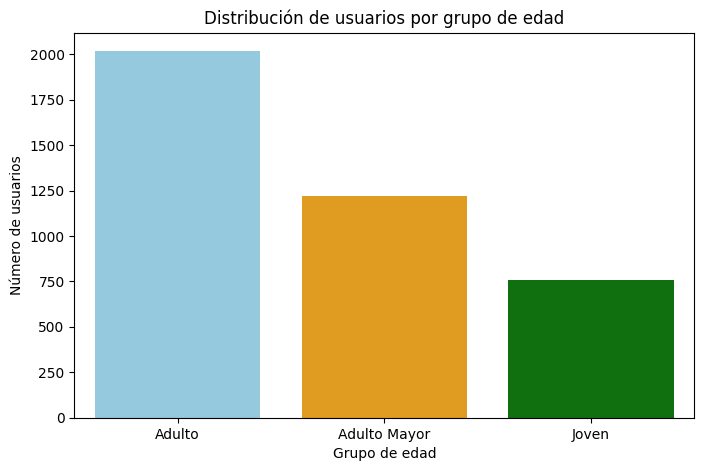

In [92]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8,5))

sns.countplot(
    data=user_profile,
    x='grupo_edad',
    palette=['skyblue', 'orange', 'green']
)

plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Número de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Durante la etapa de exploración se identificaron diversos problemas de calidad que requerían limpieza antes de realizar cualquier análisis.

- La columna city presentaba 469 valores nulos (11.7%) y 96 registros con el valor sentinel "?" (2.4%), los cuales fueron reemplazados por valores nulos al representar información desconocida.
- La columna churn_date contenía 3,534 valores nulos (88.35%). Este porcentaje elevado es consistente con usuarios que continúan siendo clientes, por lo que se decidió conservar la información y no imputarla.
- En age se detectó el valor -999, utilizado como sentinel para representar edades desconocidas. Este valor fue reemplazado por la mediana para evitar distorsionar las estadísticas.
- Se identificaron 40 fechas de registro correspondientes al año 2026 (1%), fuera del rango esperado, considerando que el análisis contempla información hasta 2024. Estas fechas fueron marcadas como valores nulos.
- En la tabla usage, los valores nulos de duration y length no representan errores, sino un comportamiento esperado del modelo de datos:
duration aparece nulo en registros de tipo text.
length aparece nulo en registros de tipo call.
- Estos casos fueron clasificados como Missing At Random (MAR) y se conservaron sin imputación.


🔍 **Segmentos por Edad**

La segmentación permitió clasificar a los usuarios en tres grupos: Jóvenes, Adultos y Adultos Mayores.

El análisis muestra que la mayor parte de la cartera de clientes corresponde al segmento Adulto, seguido por los Adultos Mayores, mientras que los usuarios jóvenes representan la menor proporción.

No se observaron diferencias importantes en el comportamiento de uso entre grupos de edad, lo que indica que la edad, por sí sola, no explica el tipo de plan contratado ni el nivel de consumo.

Esto sugiere que la segmentación comercial debería apoyarse principalmente en variables de comportamiento y no únicamente en variables demográficas.


📊 **Segmentos por Nivel de Uso**

Los clientes fueron clasificados en tres niveles de uso:

Bajo uso
Uso medio
Alto uso

La mayor concentración de usuarios se encuentra en los segmentos de bajo y uso medio, mientras que los clientes de alto uso representan un grupo reducido.

Este comportamiento es consistente con la distribución observada en mensajes, llamadas y minutos consumidos, donde la mayoría mantiene un consumo moderado y únicamente una minoría presenta un uso intensivo.


➡️ Esto sugiere que ...
ConnectaTel posee una base amplia de clientes con patrones de consumo relativamente bajos, mientras que existe un segmento pequeño con necesidades significativamente mayores.

Este grupo de alto consumo representa una oportunidad para incrementar ingresos mediante estrategias de upselling, programas de fidelización y planes especializados.

💡 **Recomendaciones**
Con base en los hallazgos obtenidos, se proponen las siguientes acciones para ConnectaTel:

Implementar una estrategia de segmentación basada en el comportamiento de consumo, priorizando variables como minutos de llamadas, cantidad de mensajes y frecuencia de uso, en lugar de enfocarse únicamente en variables demográficas como la edad.
Diseñar planes diferenciados para usuarios de alto consumo, ofreciendo mayores beneficios en llamadas o paquetes personalizados que incentiven la permanencia y aumenten el ingreso promedio por cliente.
Desarrollar campañas de migración hacia planes Premium dirigidas a clientes con niveles de consumo cercanos a los límites del plan Básico, aprovechando su potencial de crecimiento.
Fortalecer los procesos de calidad de datos, incorporando validaciones que impidan el registro de valores sentinel, fechas futuras y ciudades inválidas, reduciendo así el esfuerzo de limpieza en futuros análisis.
Monitorear continuamente el segmento de alto consumo, ya que representa clientes estratégicos tanto por su contribución potencial a los ingresos como por el riesgo asociado a una posible cancelación del servicio.

Conclusión 
El análisis permitió transformar una base con problemas de calidad en un conjunto de datos confiable para la toma de decisiones. Los resultados muestran que la principal fuente de diferenciación entre los clientes no es la edad, sino su comportamiento de consumo. La mayoría de los usuarios presenta un uso moderado de los servicios, mientras que un segmento reducido concentra una parte importante del consumo de llamadas y mensajería. Estos clientes de alto uso representan una oportunidad para desarrollar ofertas comerciales más personalizadas, mejorar la retención y optimizar la rentabilidad de ConnectaTel. Asimismo, se identificaron oportunidades para fortalecer la calidad de los datos desde su origen, mejorando la confiabilidad de futuros análisis y procesos de negocio.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: https://github.com/Susana-Ramirez-Severiano/telecom-analysis.git